# Statistics for LLM vs Embedder Brain Encoding


In [1]:
!pip uninstall -y pandas numpy
!pip install --no-cache-dir pandas numpy

Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     |████████████████████████████████| 12.8 MB 5.4 MB/s            
     |████████████████████████████████| 19.5 MB 65.5 MB/s            
You should consider upgrading via the '/gpfs/home1/scur0412/NeuroNLP/neuro/bin/python -m pip install --upgrade pip' command.


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from pathlib import Path
from scipy.stats import wilcoxon


In [3]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"

candidate_files = {
    'accs_qwen_exp2': [RESULTS_DIR / 'qwen_layer_performances_exp2.npy', RESULTS_DIR / 'accs_qwen_exp2.npy'],
    'accs_emb_exp2': [RESULTS_DIR / 'qwen_embedding_layer_performances_exp2.npy', RESULTS_DIR / 'accs_embedder_exp2.npy'],
    'accs_qwen_exp3': [RESULTS_DIR / 'qwen_layer_performances_exp3.npy', RESULTS_DIR / 'accs_qwen_exp3.npy'],
    'accs_emb_exp3': [RESULTS_DIR / 'qwen_embedding_layer_performances_exp3.npy', RESULTS_DIR / 'accs_embedder_exp3.npy'],
}

for var_name, paths in candidate_files.items():
    if var_name in globals():
        continue
    for path in paths:
        if path.exists():
            globals()[var_name] = np.load(path)
            print(f'Loaded {var_name} from {path}')
            break


Loaded accs_qwen_exp2 from /gpfs/home1/scur0412/NeuroNLP/results/qwen_layer_performances_exp2.npy
Loaded accs_emb_exp2 from /gpfs/home1/scur0412/NeuroNLP/results/qwen_embedding_layer_performances_exp2.npy
Loaded accs_qwen_exp3 from /gpfs/home1/scur0412/NeuroNLP/results/qwen_layer_performances_exp3.npy
Loaded accs_emb_exp3 from /gpfs/home1/scur0412/NeuroNLP/results/qwen_embedding_layer_performances_exp3.npy


In [4]:
def cohens_d_paired(x, y):
    """Cohen's d for paired samples."""
    x = np.asarray(x)
    y = np.asarray(y)
    diff = x - y
    return diff.mean() / diff.std(ddof=1)


def paired_t_with_effect(embed_scores, llm_scores, alternative="two-sided"):
    """
    Paired t-test and paired Cohen's d.
    By default, uses a two-sided test because model differences can go in either direction.
    """
    embed_scores = np.asarray(embed_scores)
    llm_scores = np.asarray(llm_scores)
    if embed_scores.shape != llm_scores.shape:
        raise ValueError("embed_scores and llm_scores must have same shape")

    try:
        t_stat, p_val = stats.ttest_rel(embed_scores, llm_scores, alternative=alternative)
    except TypeError:
        t_stat, p_two = stats.ttest_rel(embed_scores, llm_scores)
        if alternative == "greater":
            p_val = p_two / 2 if t_stat > 0 else 1 - (p_two / 2)
        elif alternative == "less":
            p_val = p_two / 2 if t_stat < 0 else 1 - (p_two / 2)
        else:
            p_val = p_two

    d = cohens_d_paired(embed_scores, llm_scores)
    return t_stat, p_val, d


Compare models at each model's own peak layer

For each participant:
- LLM score = participant's score at **LLM global peak layer**
- Embedder score = participant's score at **Embedder global peak layer**

Then run paired t-test across participants.


In [5]:
# Global peak layers based on participant-averaged curves
peak_qwen_exp2 = int(np.argmax(accs_qwen_exp2.mean(axis=0)))
peak_emb_exp2  = int(np.argmax(accs_emb_exp2.mean(axis=0)))
peak_qwen_exp3 = int(np.argmax(accs_qwen_exp3.mean(axis=0)))
peak_emb_exp3  = int(np.argmax(accs_emb_exp3.mean(axis=0)))

print("Peak layers")
print(f"Exp2 LLM={peak_qwen_exp2}, Embedder={peak_emb_exp2}")
print(f"Exp3 LLM={peak_qwen_exp3}, Embedder={peak_emb_exp3}")

exp2_llm_peak_scores = accs_qwen_exp2[:, peak_qwen_exp2]
exp2_emb_peak_scores = accs_emb_exp2[:, peak_emb_exp2]
exp3_llm_peak_scores = accs_qwen_exp3[:, peak_qwen_exp3]
exp3_emb_peak_scores = accs_emb_exp3[:, peak_emb_exp3]

rows = []
for exp_name, emb, llm in [
    ("Exp2", exp2_emb_peak_scores, exp2_llm_peak_scores),
    ("Exp3", exp3_emb_peak_scores, exp3_llm_peak_scores),
]:
    t, p, d = paired_t_with_effect(emb, llm, alternative="two-sided")
    rows.append({
        "comparison": f"{exp_name}: Embedder_peak vs LLM_peak",
        "n": len(emb),
        "embedder_mean": emb.mean(),
        "llm_mean": llm.mean(),
        "mean_diff": (emb - llm).mean(),
        "t_stat": t,
        "p_value": p,
        "cohens_d_paired": d,
    })

peak_df = pd.DataFrame(rows)
peak_df


Peak layers
Exp2 LLM=17, Embedder=10
Exp3 LLM=16, Embedder=25


,comparison,n,embedder_mean,llm_mean,mean_diff,t_stat,p_value,cohens_d_paired
0,Exp2: Embedder_peak vs LLM_peak,9,0.154540,0.148546,0.005994,0.768012,0.464544,0.256004
1,Exp3: Embedder_peak vs LLM_peak,9,0.128114,0.126732,0.001381,0.227569,0.825690,0.075856


Layer-wise paired tests + FDR correction

For each layer in each experiment:
- paired t-test across participants (Embedder = LLM)
- then FDR-correct p-values across all tested layers


In [6]:
def layerwise_paired_tests(accs_emb, accs_llm, experiment_name):
    n_layers = accs_emb.shape[1]
    rows = []

    for layer in range(n_layers):
        emb = accs_emb[:, layer]
        llm = accs_llm[:, layer]
        t, p, d = paired_t_with_effect(emb, llm, alternative="two-sided")

        rows.append({
            "experiment": experiment_name,
            "layer": layer,
            "embedder_mean": emb.mean(),
            "llm_mean": llm.mean(),
            "mean_diff": (emb - llm).mean(),
            "t_stat": t,
            "p_value": p,
            "cohens_d_paired": d,
        })

    rows_df = pd.DataFrame(rows)

    # FDR correction only on valid finite p-values
    rows_df["p_fdr_bh"] = np.nan
    rows_df["sig_fdr_0.05"] = False

    valid_mask = np.isfinite(rows_df["p_value"].values)
    valid_pvals = rows_df.loc[valid_mask, "p_value"].values

    if len(valid_pvals) > 0:
        reject, p_fdr, _, _ = multipletests(
            valid_pvals,
            alpha=0.05,
            method="fdr_bh"
        )
        rows_df.loc[valid_mask, "p_fdr_bh"] = p_fdr
        rows_df.loc[valid_mask, "sig_fdr_0.05"] = reject

    return rows_df


In [7]:
print("Exp2 significant layers after FDR:")
display(layer_exp2_df[layer_exp2_df["sig_fdr_0.05"]][["layer", "p_value", "p_fdr_bh", "cohens_d_paired", "mean_diff"]])

print("Exp3 significant layers after FDR:")
display(layer_exp3_df[layer_exp3_df["sig_fdr_0.05"]][["layer", "p_value", "p_fdr_bh", "cohens_d_paired", "mean_diff"]])


Exp2 significant layers after FDR:


NameError: name 'layer_exp2_df' is not defined

same-layer paired comparisons at predefined layers


In [ ]:
def paired_test_at_layer(accs_emb, accs_llm, layer, exp_name):
    emb = accs_emb[:, layer]
    llm = accs_llm[:, layer]
    t, p, d = paired_t_with_effect(emb, llm, alternative="two-sided")
    return {
        "experiment": exp_name,
        "layer": layer,
        "embedder_mean": emb.mean(),
        "llm_mean": llm.mean(),
        "mean_diff": (emb - llm).mean(),
        "t_stat": t,
        "p_value": p,
        "cohens_d_paired": d,
    }

example_layers = sorted(set([10, 16, 17, 25, 12, 22, 28]))
rows = []
for L in example_layers:
    if L < accs_emb_exp2.shape[1]:
        rows.append(paired_test_at_layer(accs_emb_exp2, accs_qwen_exp2, L, "Exp2"))
    if L < accs_emb_exp3.shape[1]:
        rows.append(paired_test_at_layer(accs_emb_exp3, accs_qwen_exp3, L, "Exp3"))

pd.DataFrame(rows)


,experiment,layer,embedder_mean,llm_mean,mean_diff,t_stat,p_value,cohens_d_paired
0,Exp2,10,0.154540,0.140889,0.013650,1.896079,0.094537,0.632026
1,Exp3,10,0.123357,0.119936,0.003420,0.877194,0.405952,0.292398
2,Exp2,12,0.152601,0.145372,0.007229,1.133002,0.290025,0.377667
3,Exp3,12,0.117537,0.123545,-0.006008,-1.279420,0.236606,-0.426473
4,Exp2,16,0.144980,0.146587,-0.001607,-0.254179,0.805769,-0.084726
5,Exp3,16,0.116253,0.126732,-0.010480,-1.985525,0.082341,-0.661842
6,Exp2,17,0.139115,0.148546,-0.009431,-1.493320,0.173704,-0.497773
7,Exp3,17,0.116891,0.124729,-0.007838,-1.710963,0.125453,-0.570321
8,Exp2,22,0.119443,0.143183,-0.023740,-3.293678,0.010962,-1.097893
9,Exp3,22,0.113083,0.118589,-0.005506,-0.617992,0.553762,-0.205997


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = layerwise_df.copy()

plt.figure(figsize=(11, 5))
plt.axhline(0, linestyle="--", linewidth=1)

for exp_name in sorted(plot_df["experiment"].unique()):
    exp_df = plot_df[plot_df["experiment"] == exp_name].copy()

    plt.plot(
        exp_df["layer"],
        exp_df["cohens_d_paired"],
        marker="o",
        label=f"{exp_name}: paired Cohen's d"
    )

    sig_df = exp_df[exp_df["sig_fdr_0.05"] == True]

    if len(sig_df) > 0:
        plt.scatter(
            sig_df["layer"],
            sig_df["cohens_d_paired"],
            s=110,
            marker="*",
            label=f"{exp_name}: FDR-significant"
        )

plt.xlabel("Layer")
plt.ylabel("Paired Cohen's d (Qwen3-Embedding − Qwen3)")
plt.title("Layer-wise paired model differences in voxel-encoding performance")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'layerwise_df' is not defined

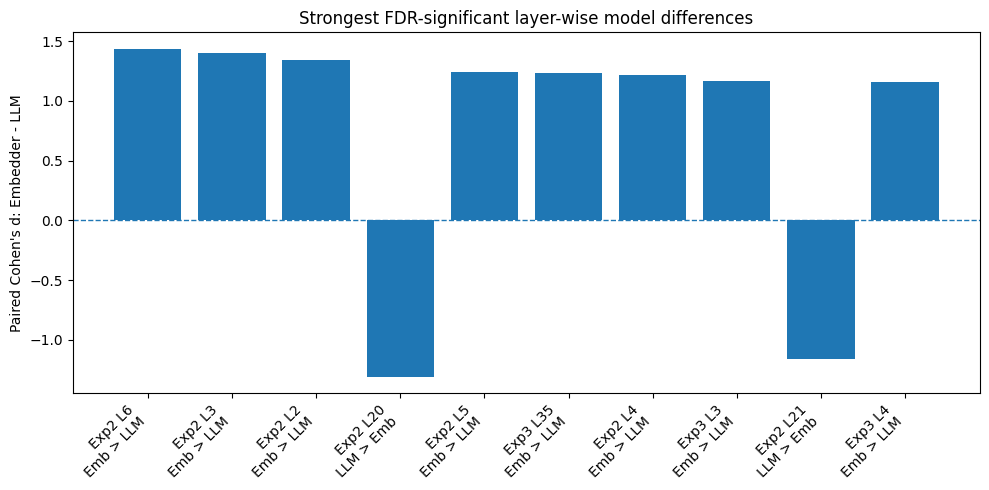

,experiment,layer,embedder_mean,llm_mean,mean_diff,t_stat,p_value,p_fdr_bh,cohens_d_paired
6,Exp2,6,0.138883,0.104294,0.034588,4.306396,0.002593,0.040046,1.435465
3,Exp2,3,0.099521,0.054286,0.045235,4.203767,0.002981,0.040046,1.401256
2,Exp2,2,0.092944,0.064289,0.028655,4.031026,0.003783,0.040046,1.343675
20,Exp2,20,0.122433,0.144971,-0.022538,-3.925545,0.004384,0.040046,-1.308515
5,Exp2,5,0.123223,0.093435,0.029788,3.733245,0.005761,0.040046,1.244415
72,Exp3,35,0.115083,0.089596,0.025487,3.695618,0.006081,NaN,1.231873
4,Exp2,4,0.118194,0.080812,0.037382,3.650046,0.006494,0.040046,1.216682
40,Exp3,3,0.102314,0.062176,0.040138,3.490898,0.008188,NaN,1.163633
21,Exp2,21,0.121884,0.144529,-0.022646,-3.488245,0.008220,0.043446,-1.162748
41,Exp3,4,0.111414,0.081162,0.030252,3.475194,0.008379,NaN,1.158398


In [ ]:
sig_layers = layerwise_df[layerwise_df["sig_fdr_0.05"] == True].copy()

if len(sig_layers) == 0:
    print("No FDR-significant layer-wise differences found.")
else:
    sig_layers["abs_d"] = sig_layers["cohens_d_paired"].abs()
    sig_layers = sig_layers.sort_values("abs_d", ascending=False)

    top_sig = sig_layers.head(10).copy()

    top_sig["label"] = (
        top_sig["experiment"]
        + " L"
        + top_sig["layer"].astype(str)
        + "\n"
        + np.where(
            top_sig["cohens_d_paired"] > 0,
            "Emb > LLM",
            "LLM > Emb"
        )
    )

    plt.figure(figsize=(10, 5))

    plt.bar(
        top_sig["label"],
        top_sig["cohens_d_paired"]
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.ylabel("Paired Cohen's d: Embedder - LLM")
    plt.title("Strongest FDR-significant layer-wise model differences")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(
        top_sig[
            [
                "experiment",
                "layer",
                "embedder_mean",
                "llm_mean",
                "mean_diff",
                "t_stat",
                "p_value",
                "p_fdr_bh",
                "cohens_d_paired",
            ]
        ]
    )

In [ ]:
out_dir = RESULTS_DIR / "statistics"
out_dir.mkdir(parents=True, exist_ok=True)

peak_df.to_csv(out_dir / "paired_peak_tests.csv", index=False)
layerwise_df.to_csv(out_dir / "paired_layerwise_tests_fdr.csv", index=False)

print("Saved:")
print(out_dir / "paired_peak_tests.csv")
print(out_dir / "paired_layerwise_tests_fdr.csv")


NameError: name 'layerwise_df' is not defined

In [ ]:
# Global peak layers based on participant-averaged curves
peak_qwen_exp2 = int(np.argmax(accs_qwen_exp2.mean(axis=0)))
peak_emb_exp2  = int(np.argmax(accs_emb_exp2.mean(axis=0)))
peak_qwen_exp3 = int(np.argmax(accs_qwen_exp3.mean(axis=0)))
peak_emb_exp3  = int(np.argmax(accs_emb_exp3.mean(axis=0)))

print("Peak layers")
print(f"Exp2 LLM={peak_qwen_exp2}, Embedder={peak_emb_exp2}")
print(f"Exp3 LLM={peak_qwen_exp3}, Embedder={peak_emb_exp3}")

exp2_llm_peak_scores = accs_qwen_exp2[:, peak_qwen_exp2]
exp2_emb_peak_scores = accs_emb_exp2[:, peak_emb_exp2]
exp3_llm_peak_scores = accs_qwen_exp3[:, peak_qwen_exp3]
exp3_emb_peak_scores = accs_emb_exp3[:, peak_emb_exp3]

rows = []
for exp_name, emb, llm in [
    ("Exp2", exp2_emb_peak_scores, exp2_llm_peak_scores),
    ("Exp3", exp3_emb_peak_scores, exp3_llm_peak_scores),
]:
    t, p, d = wilcoxon(emb, llm, alternative="two-sided")
    rows.append({
        "comparison": f"{exp_name}: Embedder_peak vs LLM_peak",
        "n": len(emb),
        "embedder_mean": emb.mean(),
        "llm_mean": llm.mean(),
        "mean_diff": (emb - llm).mean(),
        "t_stat": t,
        "p_value": p,
        "cohens_d_paired": d,
    })

peak_df = pd.DataFrame(rows)
peak_df

NameError: name 'np' is not defined

In [ ]:
from scipy.stats import wilcoxon

def wilcoxon_with_effect(embed_scores, llm_scores, alternative="two-sided"):
    embed_scores = np.asarray(embed_scores)
    llm_scores   = np.asarray(llm_scores)
    diff = embed_scores - llm_scores
    stat, p_val = wilcoxon(diff, alternative=alternative, zero_method="wilcox")
    d = cohens_d_paired(embed_scores, llm_scores)  
    return stat, p_val, d

In [ ]:
rows = []
for exp_name, emb, llm in [
    ("Exp2", exp2_emb_peak_scores, exp2_llm_peak_scores),
    ("Exp3", exp3_emb_peak_scores, exp3_llm_peak_scores),
]:
    W, p, d = wilcoxon_with_effect(emb, llm)
    rows.append({
        "comparison": f"{exp_name}: Embedder_peak vs LLM_peak",
        "n": len(emb),
        "embedder_mean": emb.mean(),
        "llm_mean": llm.mean(),
        "W_stat": W,
        "p_value": p,
        "cohens_d_paired": d,
    })
pd.DataFrame(rows)

In [ ]:
import matplotlib.pyplot as plt

layerwise_wilcox_df = pd.concat([layer_exp2_wilcox, layer_exp3_wilcox], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0, linestyle="--", linewidth=1)

colors = {"Exp2": "darkorange", "Exp3": "steelblue"}

for exp_name in ["Exp2", "Exp3"]:
    exp_df = layerwise_wilcox_df[layerwise_wilcox_df["experiment"] == exp_name]
    ax.plot(
        exp_df["layer"],
        exp_df["cohens_d_paired"],
        marker="o", markersize=4,
        color=colors[exp_name],
        label=f"{exp_name}: paired Cohen's d"
    )
    sig_df = exp_df[exp_df["sig_fdr_0.05"]]
    if len(sig_df) > 0:
        ax.scatter(
            sig_df["layer"],
            sig_df["cohens_d_paired"],
            s=110, marker="*",
            color=colors[exp_name],
            label=f"{exp_name}: FDR-significant (Wilcoxon)"
        )

ax.set_xlabel("Layer")
ax.set_ylabel("Paired Cohen's d (Qwen3-Embedding − Qwen3)")
ax.set_title("Layer-wise paired model differences in voxel-encoding performance\n(Wilcoxon signed-rank test, FDR-corrected)")
ax.legend()
plt.tight_layout()
plt.savefig("figure2_wilcoxon.png", dpi=150)
plt.show()